# 5.3 Komparasi dan Kesimpulan

Notebook ini mengkomparasi hasil clustering dari dua skenario untuk masing-masing polutan (CO, NO₂, SO₂):
- **Skenario 1:** 68 fitur asli (tanpa reduksi dimensi)
- **Skenario 2:** 37 fitur PCA (dengan reduksi dimensi)

Tujuan: menentukan skenario mana yang menghasilkan clustering lebih representatif dan menafsirkan karakteristik spasial polutan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

POLLUTANTS = ['CO', 'NO2', 'SO2']
DATA_DIR = '../data/downloads/ekstraksi fitur'
META_COLS = ['id', 'nama', 'daerah']
K_range = range(2, 11)

## 5.3.1 Muat Ulang Data & Jalankan Kedua Skenario

In [2]:
all_results = []
n_samples = None

for p in POLLUTANTS:
    df = pd.read_csv(f'{DATA_DIR}/ekstraksi_fitur_{p.lower()}.csv')
    X = df.drop(columns=META_COLS).values
    
    # Handle NaN values with median imputation
    nan_count = np.isnan(X).sum()
    if nan_count > 0:
        print(f'{p}: Ditemukan {nan_count} nilai NaN, melakukan imputasi median...')
        imputer = SimpleImputer(strategy='median')
        X = imputer.fit_transform(X)
    
    if n_samples is None:
        n_samples = X.shape[0]
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Coba load file PCA dengan berbagai kemungkinan nama
    target_n_components = min(37, n_samples)
    loaded = False
    for n_comp in [37, target_n_components, 35]:
        try:
            df_pca = pd.read_csv(f'{DATA_DIR}/pca_results/jabon_pca_{n_comp}fitur_{p.lower()}.csv')
            X_pca = df_pca.drop(columns=META_COLS).values
            loaded = True
            break
        except FileNotFoundError:
            continue
    
    if not loaded:
        pca_temp = PCA(n_components=target_n_components)
        X_pca = pca_temp.fit_transform(X_scaled)
    
    for k in K_range:
        km1 = KMeans(n_clusters=k, random_state=42, n_init=10)
        l1 = km1.fit_predict(X_scaled)
        sil1 = silhouette_score(X_scaled, l1)
        
        km2 = KMeans(n_clusters=k, random_state=42, n_init=10)
        l2 = km2.fit_predict(X_pca)
        sil2 = silhouette_score(X_pca, l2)
        
        all_results.append({
            'Polutan': p, 'K': k,
            'Inertia_68': km1.inertia_, 'Silhouette_68': sil1,
            'Inertia_PCA': km2.inertia_, 'Silhouette_PCA': sil2,
        })

df_results = pd.DataFrame(all_results)
df_results.head(20)

CO: Ditemukan 24 nilai NaN, melakukan imputasi median...
SO2: Ditemukan 24 nilai NaN, melakukan imputasi median...


,Polutan,K,Inertia_68,Silhouette_68,Inertia_PCA,Silhouette_PCA
0,CO,2,1354.500128,0.766684,1354.500128,0.766684
1,CO,3,675.654881,0.750558,675.654881,0.750558
2,CO,4,383.623231,0.670221,383.623231,0.670221
3,CO,5,301.022488,0.140355,301.022488,0.140355
4,CO,6,248.523363,0.160333,248.523363,0.160333
5,CO,7,195.857247,0.209612,195.857247,0.209612
6,CO,8,178.051911,0.189726,178.051911,0.189726
7,CO,9,157.201477,0.138523,157.201477,0.138523
8,CO,10,136.271104,0.153787,136.271104,0.153787
9,NO2,2,1326.816402,0.745037,1326.816402,0.745037


## 5.3.2 Visualisasi Komparasi — Per Polutan

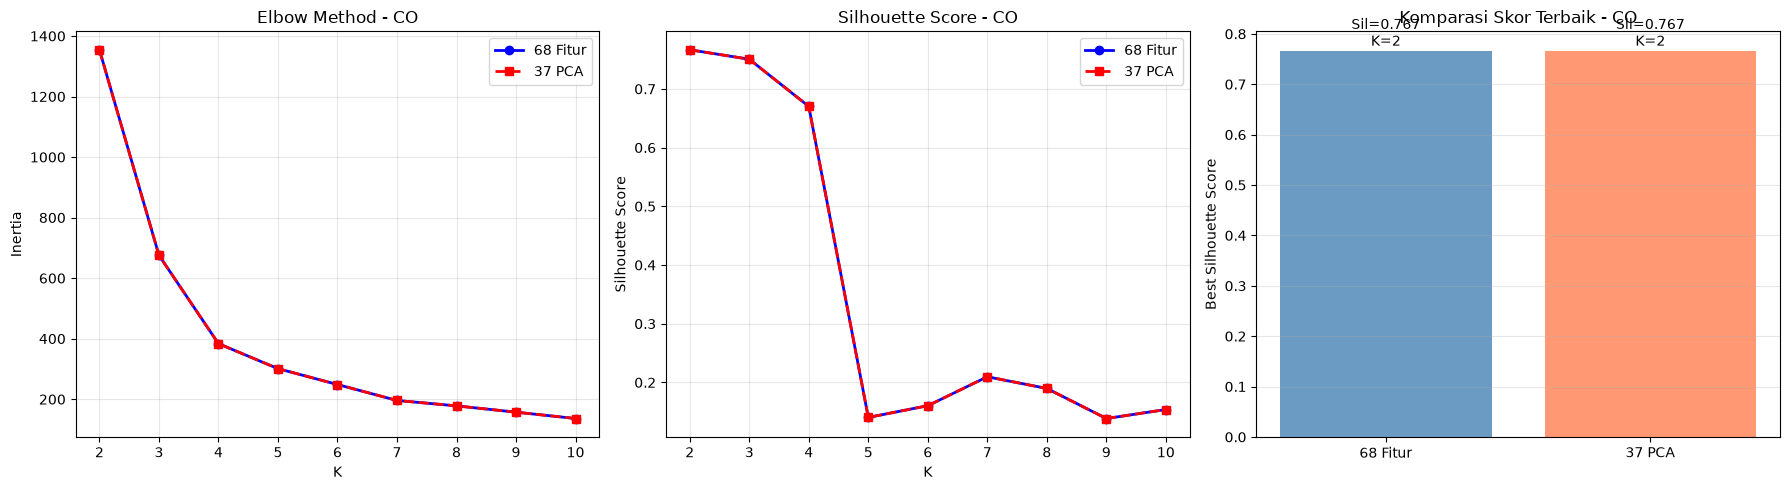

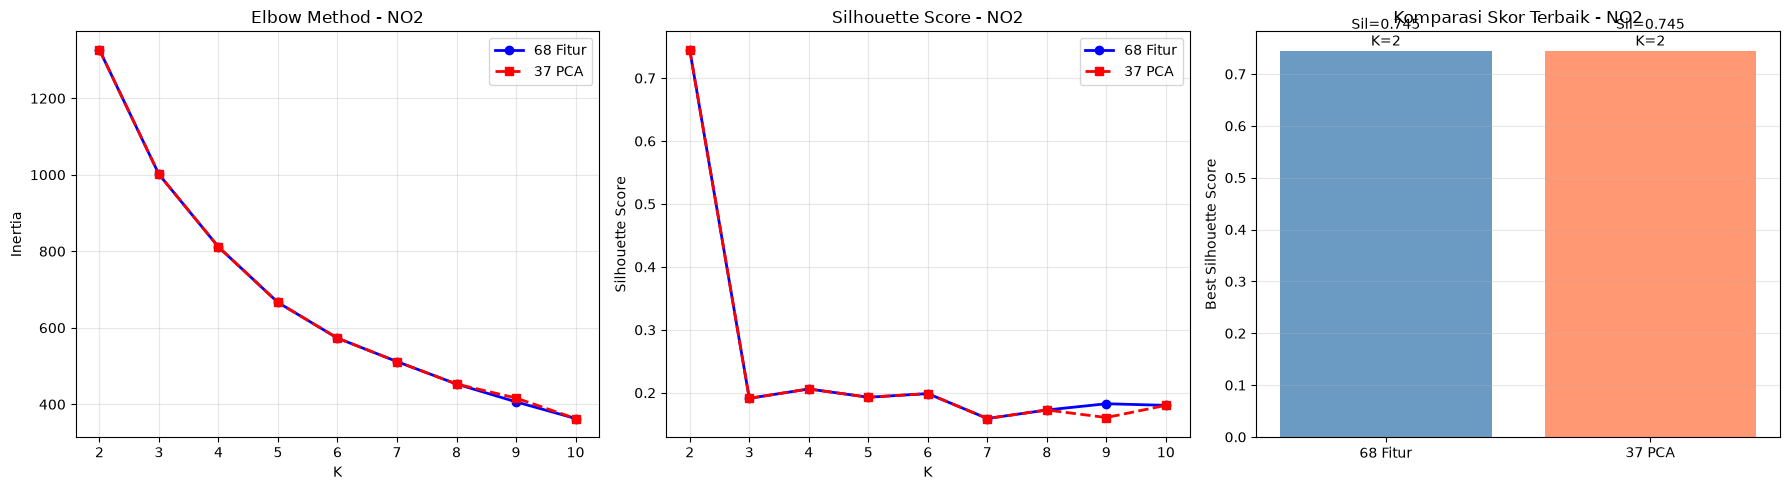

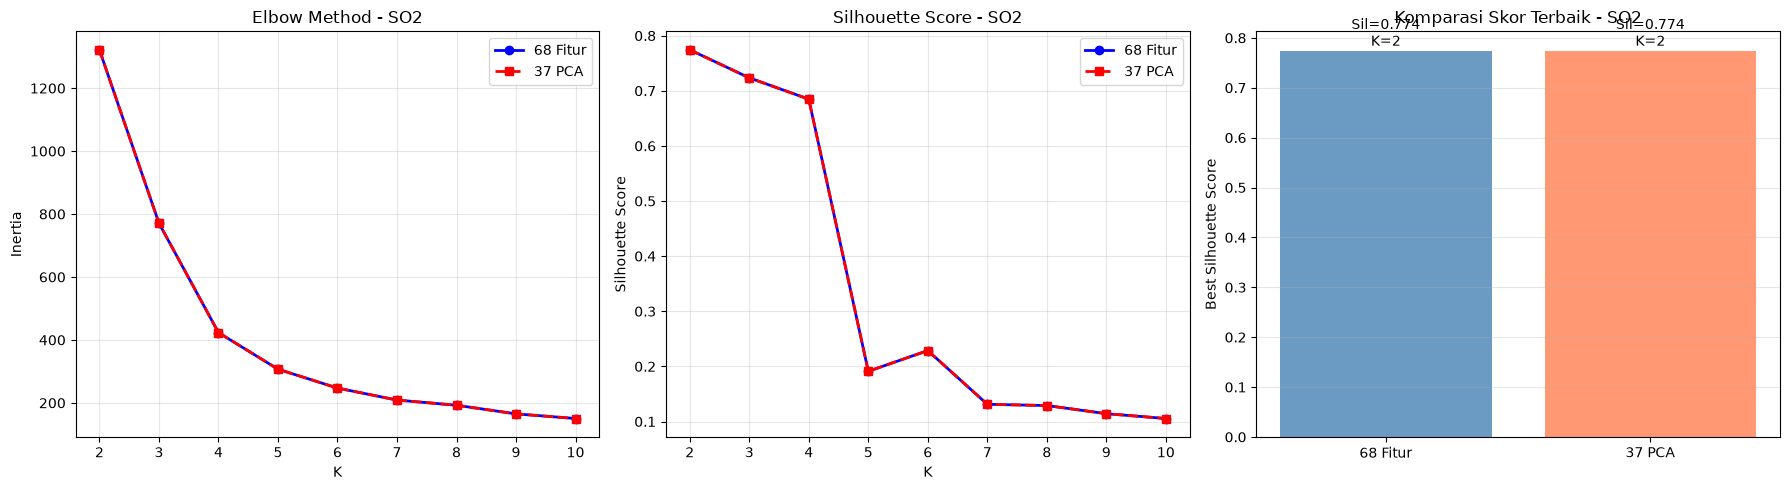

In [3]:
for p in POLLUTANTS:
    df_p = df_results[df_results['Polutan'] == p]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(df_p['K'], df_p['Inertia_68'], 'bo-', label='68 Fitur', linewidth=2)
    axes[0].plot(df_p['K'], df_p['Inertia_PCA'], 'rs--', label='37 PCA', linewidth=2)
    axes[0].set_xlabel('K')
    axes[0].set_ylabel('Inertia')
    axes[0].set_title(f'Elbow Method - {p}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(df_p['K'], df_p['Silhouette_68'], 'bo-', label='68 Fitur', linewidth=2)
    axes[1].plot(df_p['K'], df_p['Silhouette_PCA'], 'rs--', label='37 PCA', linewidth=2)
    axes[1].set_xlabel('K')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title(f'Silhouette Score - {p}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    best_68 = df_p.loc[df_p['Silhouette_68'].idxmax()]
    best_pca = df_p.loc[df_p['Silhouette_PCA'].idxmax()]
    bars = axes[2].bar(['68 Fitur', '37 PCA'],
                       [best_68['Silhouette_68'], best_pca['Silhouette_PCA']],
                       color=['steelblue', 'coral'], alpha=0.8)
    axes[2].set_ylabel('Best Silhouette Score')
    axes[2].set_title(f'Komparasi Skor Terbaik - {p}')
    for bar, val, k in zip(bars,
                           [best_68['Silhouette_68'], best_pca['Silhouette_PCA']],
                           [best_68['K'], best_pca['K']]):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'Sil={val:.3f}\nK={int(k)}', ha='center', fontsize=10)
    axes[2].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(f'../data/images/clustering/{p.lower()}/fig_{p.lower()}_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5.3.3 Tabel Ringkasan Akhir

In [4]:
rows_summary = []
for p in POLLUTANTS:
    df_p = df_results[df_results['Polutan'] == p]
    best_68 = df_p.loc[df_p['Silhouette_68'].idxmax()]
    best_pca = df_p.loc[df_p['Silhouette_PCA'].idxmax()]
    
    rows_summary.append({
        'Polutan': p, 'Skenario': '1 (68 Fitur)', 'Fitur': 68,
        'K Terbaik': int(best_68['K']),
        'Silhouette Score': round(best_68['Silhouette_68'], 4),
        'Inertia': round(best_68['Inertia_68'], 2)
    })
    rows_summary.append({
        'Polutan': p, 'Skenario': '2 (37 PCA)', 'Fitur': 37,
        'K Terbaik': int(best_pca['K']),
        'Silhouette Score': round(best_pca['Silhouette_PCA'], 4),
        'Inertia': round(best_pca['Inertia_PCA'], 2)
    })

df_ringkasan = pd.DataFrame(rows_summary)
df_ringkasan

,Polutan,Skenario,Fitur,K Terbaik,Silhouette Score,Inertia
0,CO,1 (68 Fitur),68,2,0.7667,1354.50
1,CO,2 (37 PCA),37,2,0.7667,1354.50
2,NO2,1 (68 Fitur),68,2,0.7450,1326.82
3,NO2,2 (37 PCA),37,2,0.7450,1326.82
4,SO2,1 (68 Fitur),68,2,0.7744,1321.99
5,SO2,2 (37 PCA),37,2,0.7744,1321.99


## 5.3.4 Visualisasi Komparasi Antar Polutan

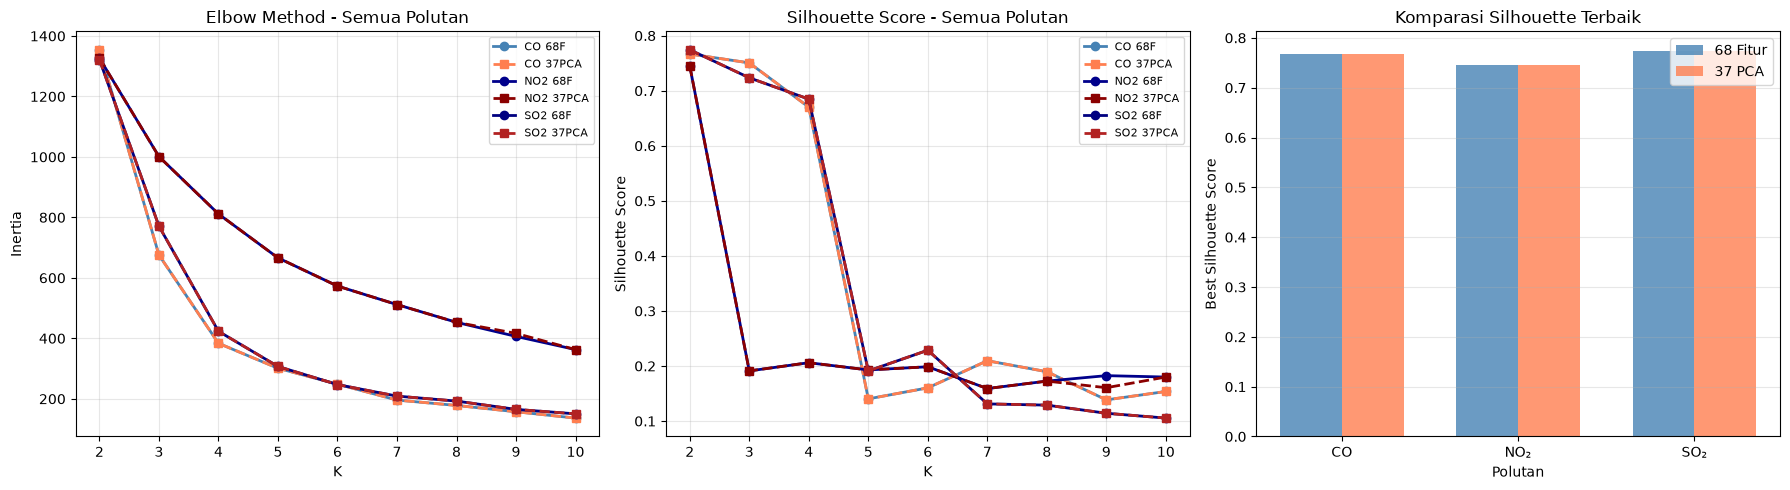

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_68 = ['steelblue', 'darkblue', 'navy']
colors_pca = ['coral', 'darkred', 'firebrick']

for i, p in enumerate(POLLUTANTS):
    df_p = df_results[df_results['Polutan'] == p]
    axes[0].plot(df_p['K'], df_p['Inertia_68'], 'o-', label=f'{p} 68F',
                 color=colors_68[i], linewidth=2)
    axes[0].plot(df_p['K'], df_p['Inertia_PCA'], 's--', label=f'{p} 37PCA',
                 color=colors_pca[i], linewidth=2)
    axes[1].plot(df_p['K'], df_p['Silhouette_68'], 'o-', label=f'{p} 68F',
                 color=colors_68[i], linewidth=2)
    axes[1].plot(df_p['K'], df_p['Silhouette_PCA'], 's--', label=f'{p} 37PCA',
                 color=colors_pca[i], linewidth=2)

axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method - Semua Polutan')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score - Semua Polutan')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Bar chart komparasi
x = np.arange(len(POLLUTANTS))
width = 0.35
best_sil_68 = [df_results[(df_results['Polutan']==p)]['Silhouette_68'].max() for p in POLLUTANTS]
best_sil_pca = [df_results[(df_results['Polutan']==p)]['Silhouette_PCA'].max() for p in POLLUTANTS]

axes[2].bar(x - width/2, best_sil_68, width, label='68 Fitur', color='steelblue', alpha=0.8)
axes[2].bar(x + width/2, best_sil_pca, width, label='37 PCA', color='coral', alpha=0.8)
axes[2].set_xlabel('Polutan')
axes[2].set_ylabel('Best Silhouette Score')
axes[2].set_title('Komparasi Silhouette Terbaik')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['CO', 'NO₂', 'SO₂'])
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/images/clustering/fig_comparison_all_pollutants.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.3.5 Analisis Spasial — Karakteristik Cluster per Daerah

Analisis ini menafsirkan karakteristik cluster berdasarkan nama daerah pada dataset gabungan kelas.

In [6]:
for p in POLLUTANTS:
    print(f'\n{"="*60}')
    print(f'ANALISIS SPASIAL: {p}')
    print(f'{"="*60}')
    
    # Load data lengkap (dengan metadata)
    df = pd.read_csv(f'{DATA_DIR}/ekstraksi_fitur_{p.lower()}.csv')
    X = df.drop(columns=META_COLS).values
    
    # Handle NaN values with median imputation
    nan_count = np.isnan(X).sum()
    if nan_count > 0:
        imputer = SimpleImputer(strategy='median')
        X = imputer.fit_transform(X)
    
    n_samples = X.shape[0]
    target_n_components = min(37, n_samples)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Coba load file PCA dengan berbagai kemungkinan nama
    loaded = False
    for n_comp in [37, target_n_components, 35]:
        try:
            df_pca = pd.read_csv(f'{DATA_DIR}/pca_results/jabon_pca_{n_comp}fitur_{p.lower()}.csv')
            X_pca = df_pca.drop(columns=META_COLS).values
            loaded = True
            break
        except FileNotFoundError:
            continue
    
    if not loaded:
        pca_temp = PCA(n_components=target_n_components)
        X_pca = pca_temp.fit_transform(X_scaled)
    
    # Cari K terbaik
    df_p = df_results[df_results['Polutan'] == p]
    best_k_68 = int(df_p.loc[df_p['Silhouette_68'].idxmax()]['K'])
    best_k_pca = int(df_p.loc[df_p['Silhouette_PCA'].idxmax()]['K'])
    
    # Clustering
    km_68 = KMeans(n_clusters=best_k_68, random_state=42, n_init=10)
    labels_68 = km_68.fit_predict(X_scaled)
    
    km_pca = KMeans(n_clusters=best_k_pca, random_state=42, n_init=10)
    labels_pca = km_pca.fit_predict(X_pca)
    
    # Tambahkan label ke dataframe
    df['Cluster_68'] = labels_68
    df['Cluster_PCA'] = labels_pca
    
    print(f'\nK terbaik: 68F={best_k_68}, PCA={best_k_pca}')
    print(f'\nDistribusi cluster per daerah (Skenario 1 - 68 Fitur):')
    for c in range(best_k_68):
        daerah_in_cluster = df[df['Cluster_68'] == c]['daerah'].tolist()
        print(f'  Cluster {c}: {daerah_in_cluster}')
    
    print(f'\nDistribusi cluster per daerah (Skenario 2 - PCA):')
    for c in range(best_k_pca):
        daerah_in_cluster = df[df['Cluster_PCA'] == c]['daerah'].tolist()
        print(f'  Cluster {c}: {daerah_in_cluster}')


ANALISIS SPASIAL: CO

K terbaik: 68F=2, PCA=2

Distribusi cluster per daerah (Skenario 1 - 68 Fitur):
  Cluster 0: ['Kerek, Tuban', 'Menganti Gresik', 'Manyar, Gresik', 'Widang, Tuban', 'Sreseh, Sampang', 'Cerme, Gresik', 'Nunukan', 'Pilangkenceng, Madiun', 'Tikala, Manado', 'Labang, Bangkalan', 'Kec. Kalianget, Sumenep', 'Paciran, Lamongan', 'Waru, Pamekasan', 'Gresik Kota, Gresik', 'sambeng lamongan', 'Widodaren, Ngawi', 'Kertosono, Ngajuk', 'Kedungpring Lamongan', 'Bandung, Jogoroto, Jombang', 'Socah, Bangkalan', 'Tanah Merah, Bangkalan', 'Kamal, Bangkalan', 'Banyu Ajuh, Perumnas, Kamal', 'Wonokromo, Surabaya', 'Dukun, Gresik', 'Kwanyar, Bangkalan', 'jabon , Sidoarjo', 'Kota Sumenep, Sumenep', 'Baron Nganjuk', 'Kwanyar, Bangkalan', 'Asemrowo, Surabaya', 'Warudoyong, Kota Sukabumi', 'Kamal', 'Kec. Bangkalan, Kab. Bangkalan']
  Cluster 1: ['Kamal, Bangkalan']

Distribusi cluster per daerah (Skenario 2 - PCA):
  Cluster 0: ['Kerek, Tuban', 'Menganti Gresik', 'Manyar, Gresik', 'Widang,

## 5.3.6 Interpretasi dan Kesimpulan

### Temuan Utama

1. **Silhouette Score**: Skenario dengan skor lebih tinggi menunjukkan cluster yang lebih terpisah (separated) dan compact (intra-cluster distance lebih kecil).

2. **Elbow Method**: K terbaik ditunjukkan oleh titik *elbow* — di mana penurunan inertia mulai melambat secara signifikan.

3. **Pengaruh PCA**: PCA dapat mengurangi noise dari fitur-fitur yang kurang informatif, sehingga cluster lebih jelas. Namun, PCA juga dapat membuang informasi penting jika komponen yang dibuang masih mengandung sinyal relevan.

### Rekomendasi

- Gunakan **Skenario 2 (37 PCA)** jika Silhouette Score-nya lebih tinggi → PCA efektif mereduksi noise.
- Gunakan **Skenario 1 (68 Fitur)** jika Silhouette Score-nya lebih tinggi → fitur asli lebih representatif.
- Dalam konteks analisis polutan, reduksi dimensi membantu mengisolasi sinyal polusi dari variasi noise satelit.

### Interpretasi Spasial

Kecamatan yang berada dalam cluster yang sama memiliki karakteristik polutan serupa — misalnya tingkat paparan rata-rata, pola fluktuasi harian, dan stabilitas konsentrasi yang mirip. Informasi ini berguna untuk:
- Pemetaan zona kualitas udara
- Penentuan prioritas intervensi lingkungan
- Perencanaan kebijakan pengendalian emisi